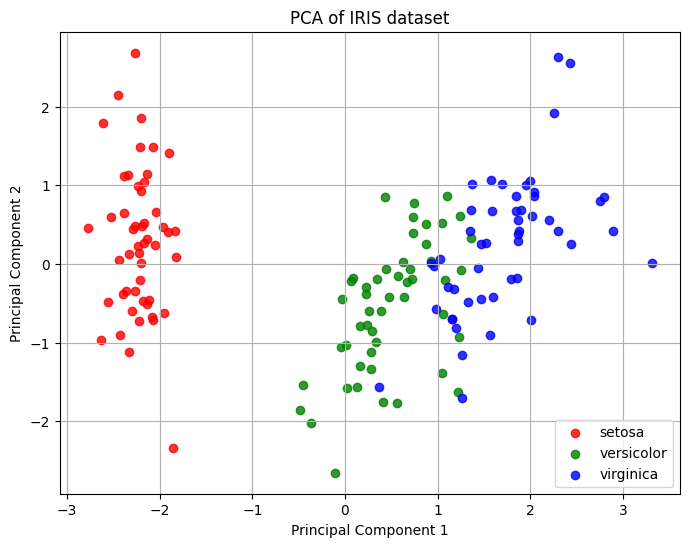

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# load iris data set
iris = datasets.load_iris()
x = iris.data
y = iris.target
target_names = iris.target_names

# standardise the data
sc = StandardScaler()
x_std = sc.fit_transform(x)

# apply pca (reduce to 2 dimensions for visualisation)
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_std)

# plot pca
plt.figure(figsize=(8,6))
colors = ['r', 'g', 'b']
for i,color, label in zip(range(len(target_names)), colors, target_names):
    plt.scatter(x_pca[y==i, 0], x_pca[y==i, 1], alpha=0.8, color=color, label=label)
plt.legend()
plt.title('PCA of IRIS dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

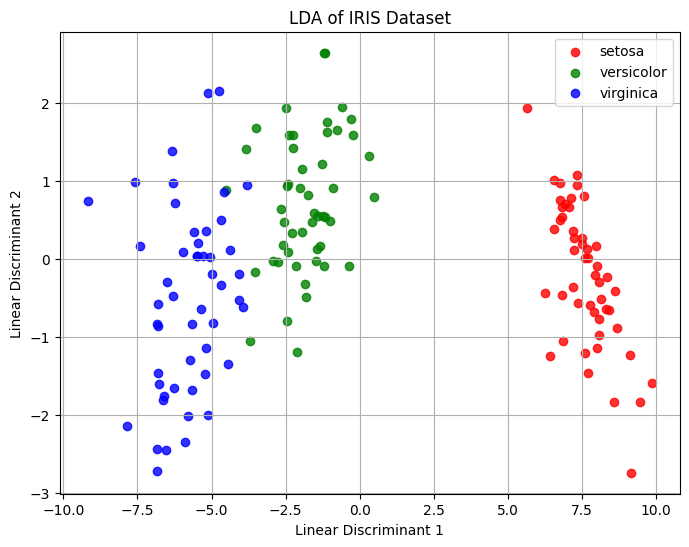

In [2]:
# apply lda (in components = number of classes - 1)
lda = LDA(n_components=2)
x_lda = lda.fit_transform(x_std, y)

# plot lda
plt.figure(figsize=(8,6))
for i,color,label in zip(range(len(target_names)), colors, target_names):
    plt.scatter(x_lda[y==i,0], x_lda[y==i,1], alpha=0.8, color=color, label=label)
plt.legend()
plt.title('LDA of IRIS Dataset')
plt.xlabel('Linear Discriminant 1')
plt.ylabel('Linear Discriminant 2')
plt.grid(True)
plt.show()

In [ ]:
import numpy as np

class PCA_from_scratch:
    def __init__(self, n_components):
        self.n_components = n_components
    def fit(self, X):  
        # mean center
        self.mean = np.mean(X, axis=0)
        X = X - self.mean
            
        # covariance matrix
        cov = np.cov(X.T)
        
        # eigenvalues and eigenvectors
        eigenvalues, eigenvectors = np.linalg.eig(cov)
        
        # sort eigenvectors
        idx = np.argsort(eigenvalues)[::-1]
        eigenvectors = eigenvectors[:, idx]
        
        # keep top components
        self.components = eigenvectors[:, :self.n_components]
        
    def transform(self, X):
        X = X - self.mean
        return np.dot(X, self.components)

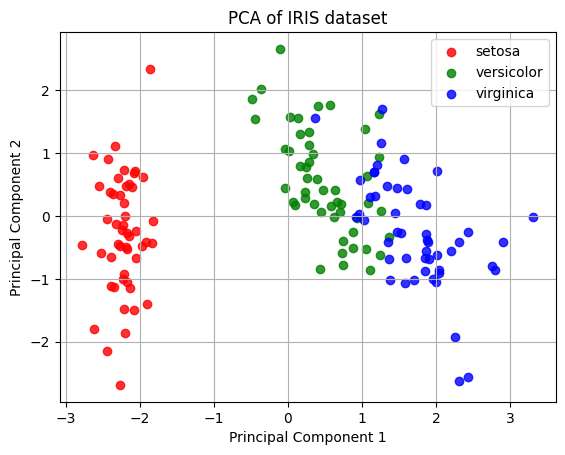

In [5]:
pca = PCA_from_scratch(n_components=2)
pca.fit(x_std)

x_pca = pca.transform(x_std)

colors = ['r', 'g', 'b']
for i,color, label in zip(range(len(target_names)), colors, target_names):
    plt.scatter(x_pca[y==i, 0], x_pca[y==i, 1], alpha=0.8, color=color, label=label)
plt.legend()
plt.title('PCA of IRIS dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

In [ ]:
class LDA_from_scratch:
    def __init__(self, n_components):
        self.n_components = n_components 
    def fit(self, X, y):
        
        n_features = X.shape[1]
        class_labels = np.unique(y)
        
        # mean of entire dataset
        mean_overall = np.mean(X, axis=0)
        
        # scatter matrices
        Sw = np.zeros((n_features, n_features))
        Sb = np.zeros((n_features, n_features))
        
        for c in class_labels:
            X_c = X[y == c]
            mean_c = np.mean(X_c, axis=0)
            
            # within-class scatter
            Sw += (X_c - mean_c).T.dot(X_c - mean_c)
            
            # between-class scatter
            n_c = X_c.shape[0]
            mean_diff = (mean_c - mean_overall).reshape(n_features,1)
            Sb += n_c * (mean_diff).dot(mean_diff.T)
        
        # solve eigenvalue problem
        A = np.linalg.inv(Sw).dot(Sb)
        eigenvalues, eigenvectors = np.linalg.eig(A)
        
        # sort eigenvectors
        idx = np.argsort(eigenvalues)[::-1]
        eigenvectors = eigenvectors[:, idx]
        
        self.components = eigenvectors[:, :self.n_components]
        
    def transform(self, X):
        return np.dot(X, self.components)

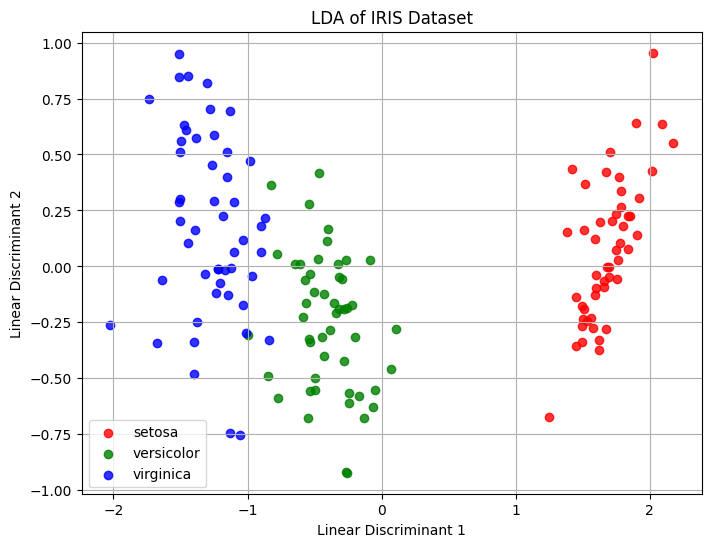

In [7]:
lda = LDA_from_scratch(n_components=2)
lda.fit(x_std, y)
x_lda = lda.transform(x_std)

# plot lda
plt.figure(figsize=(8,6))
for i,color,label in zip(range(len(target_names)), colors, target_names):
    plt.scatter(x_lda[y==i,0], x_lda[y==i,1], alpha=0.8, color=color, label=label)
plt.legend()
plt.title('LDA of IRIS Dataset')
plt.xlabel('Linear Discriminant 1')
plt.ylabel('Linear Discriminant 2')
plt.grid(True)
plt.show()


In [8]:
# train test split
x_train_pca, x_test_pca, y_train, y_test = train_test_split(x_pca, y, test_size=0.3, random_state=42)
x_train_lda, x_test_lda, x_train, x_test = train_test_split(x_lda, y, test_size=0.3, random_state=42)

# train and evaluate logistics regression on PCA
lr_pca = LogisticRegression()
lr_pca.fit(x_train_pca, y_train)
y_pred_pca = lr_pca.predict(x_test_pca)
print('PCA Accuracy: ', accuracy_score(y_test, y_pred_pca))

# train and evaluate logistics regression on LDA
lr_lda = LogisticRegression()
lr_lda.fit(x_train_lda, y_train)
y_pred_lda = lr_lda.predict(x_test_lda)
print('LDA Accuracy: ', accuracy_score(y_test, y_pred_lda))


PCA Accuracy:  0.9111111111111111
LDA Accuracy:  1.0
